In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ProcessData():
    def __init__(self, data):
        self.data = pd.read_csv(data, usecols=range(13)).to_numpy()
    
    def data_process(self):
        data_2d = self.data.reshape(len(self.data), 13)
        df = pd.DataFrame(data_2d, columns=[f'feature_{i}' for i in range(13)])
        return df

# 데이터 로드
normal = ProcessData('normal.csv').data_process()
punch = ProcessData('punch.csv').data_process()
pinch = ProcessData('pinch.csv').data_process()
pet = ProcessData('pet.csv').data_process()

def plot(normal, punch, pinch, pet):
    datasets = [normal, punch, pinch, pet]
    titles = ['Normal', 'Punch', 'Pinch', 'Pet']

    plt.figure(figsize=(13, 10))  # 전체 Figure 크기 설정
    
    for i, (df, title) in enumerate(zip(datasets, titles)):
        plt.subplot(4, 1, i+1)  # 4행 1열 서브플롯

        # 각 행(Row)마다 하나의 그래프를 그림
        for index, row in df.iterrows():
            plt.plot(df.columns, row.values, label=f'Row {index}', alpha=0.5)  # alpha=0.5로 투명도 조절

        plt.title(title, fontsize=12, fontweight="bold")  # 각 서브플롯에 제목 추가
        plt.xlabel('Feature Index')
        plt.ylabel('Value')
        plt.ylim([0, 3000])  # Y축 범위 설정

        # 범례는 1번째 그래프에만 추가 (너무 많으면 혼란스러움)
        if i == 0:
            plt.legend(loc='upper right', ncol=2, fontsize=8)

    plt.tight_layout()  # 간격 조정
    plt.show()

# 함수 실행
plot(normal, punch, pinch, pet)


ModuleNotFoundError: No module named 'matplotlib'

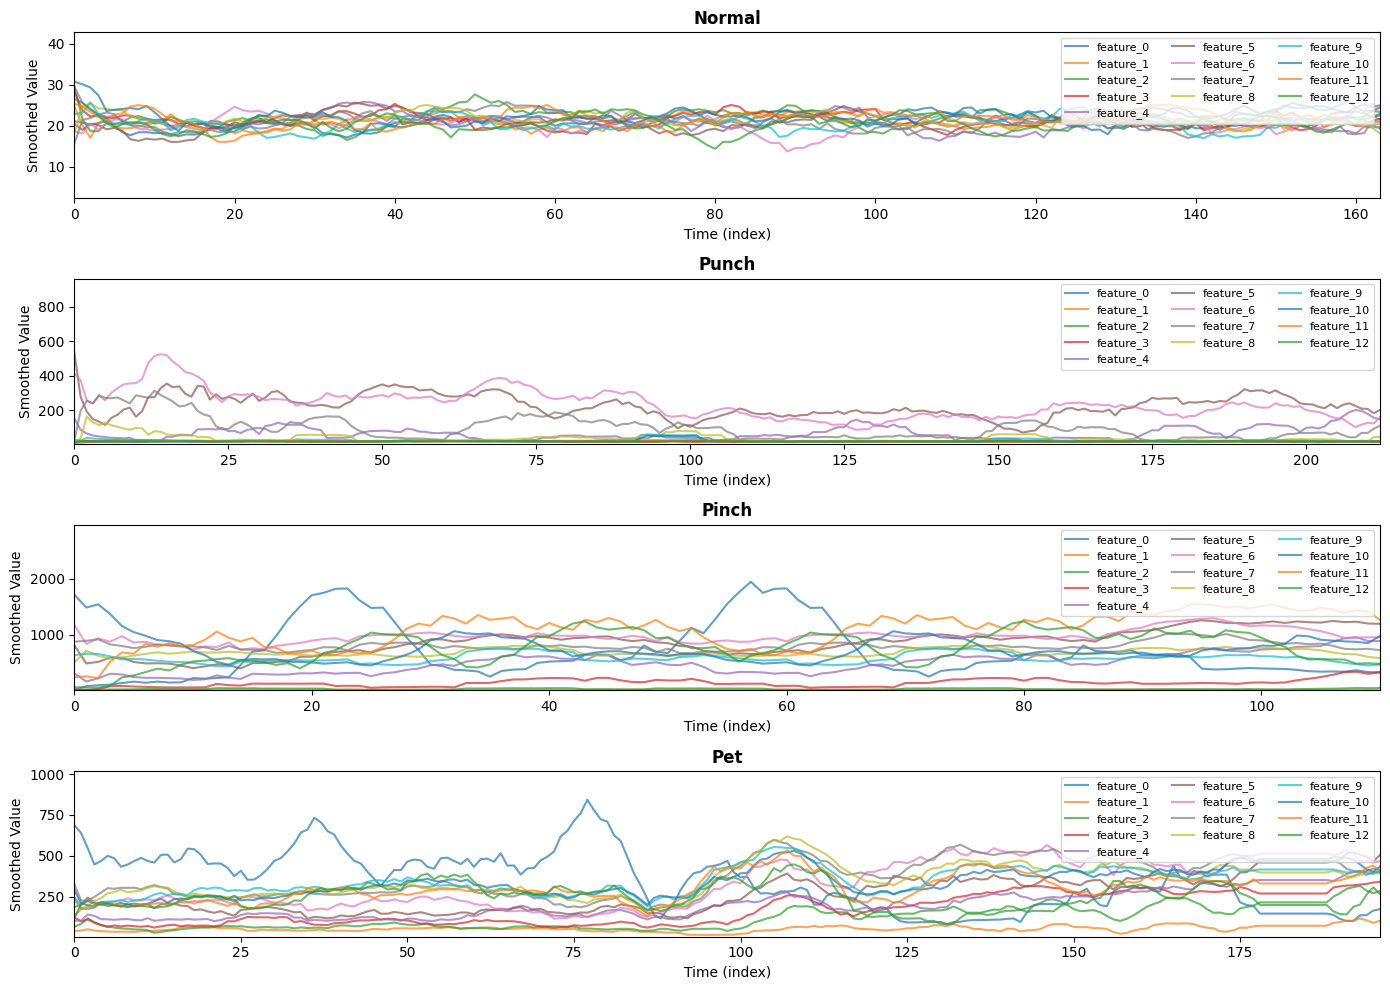

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ProcessData():
    def __init__(self, data):
        self.data = pd.read_csv(data, usecols=range(13)).to_numpy()
    
    def data_process(self):
        data_2d = self.data.reshape(len(self.data), 13)
        df = pd.DataFrame(data_2d, columns=[f'feature_{i}' for i in range(13)])
        return df

# 데이터 로드
normal = ProcessData('normal.csv').data_process()
punch = ProcessData('punch.csv').data_process()
pinch = ProcessData('pinch.csv').data_process()
pet = ProcessData('pet.csv').data_process()

def plot_smooth(normal, punch, pinch, pet, window=10):
    datasets = [normal, punch, pinch, pet]
    titles = ['Normal', 'Punch', 'Pinch', 'Pet']

    plt.figure(figsize=(14, 10))  # 전체 Figure 크기 설정
    colors = plt.cm.tab10.colors  # 색상 팔레트 사용

    for i, (df, title) in enumerate(zip(datasets, titles)):
        plt.subplot(4, 1, i+1)  # 4행 1열 서브플롯

        for idx, col in enumerate(df.columns):
            smoothed = df[col].rolling(window=window, min_periods=1).mean()  # 이동 평균 적용
            plt.plot(df.index, smoothed, label=col, color=colors[idx % len(colors)], alpha=0.7)

        plt.xlim(df.index.min(), df.index.max())  # 동일한 X축 범위 설정
        plt.ylim(df.min().min(), df.max().max())  # Y축 범위 설정
        plt.title(title, fontsize=12, fontweight="bold")
        plt.xlabel('Time (index)')
        plt.ylabel('Smoothed Value')
        plt.legend(loc='upper right', ncol=3, fontsize=8)

    plt.tight_layout()  # 간격 조정
    plt.show()

# 개선된 플롯 실행
plot_smooth(normal, punch, pinch, pet, window=10)



C:\Users\space\AppData\Local\Temp\ipykernel_3028\135409355.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right', ncol=2, fontsize=8)


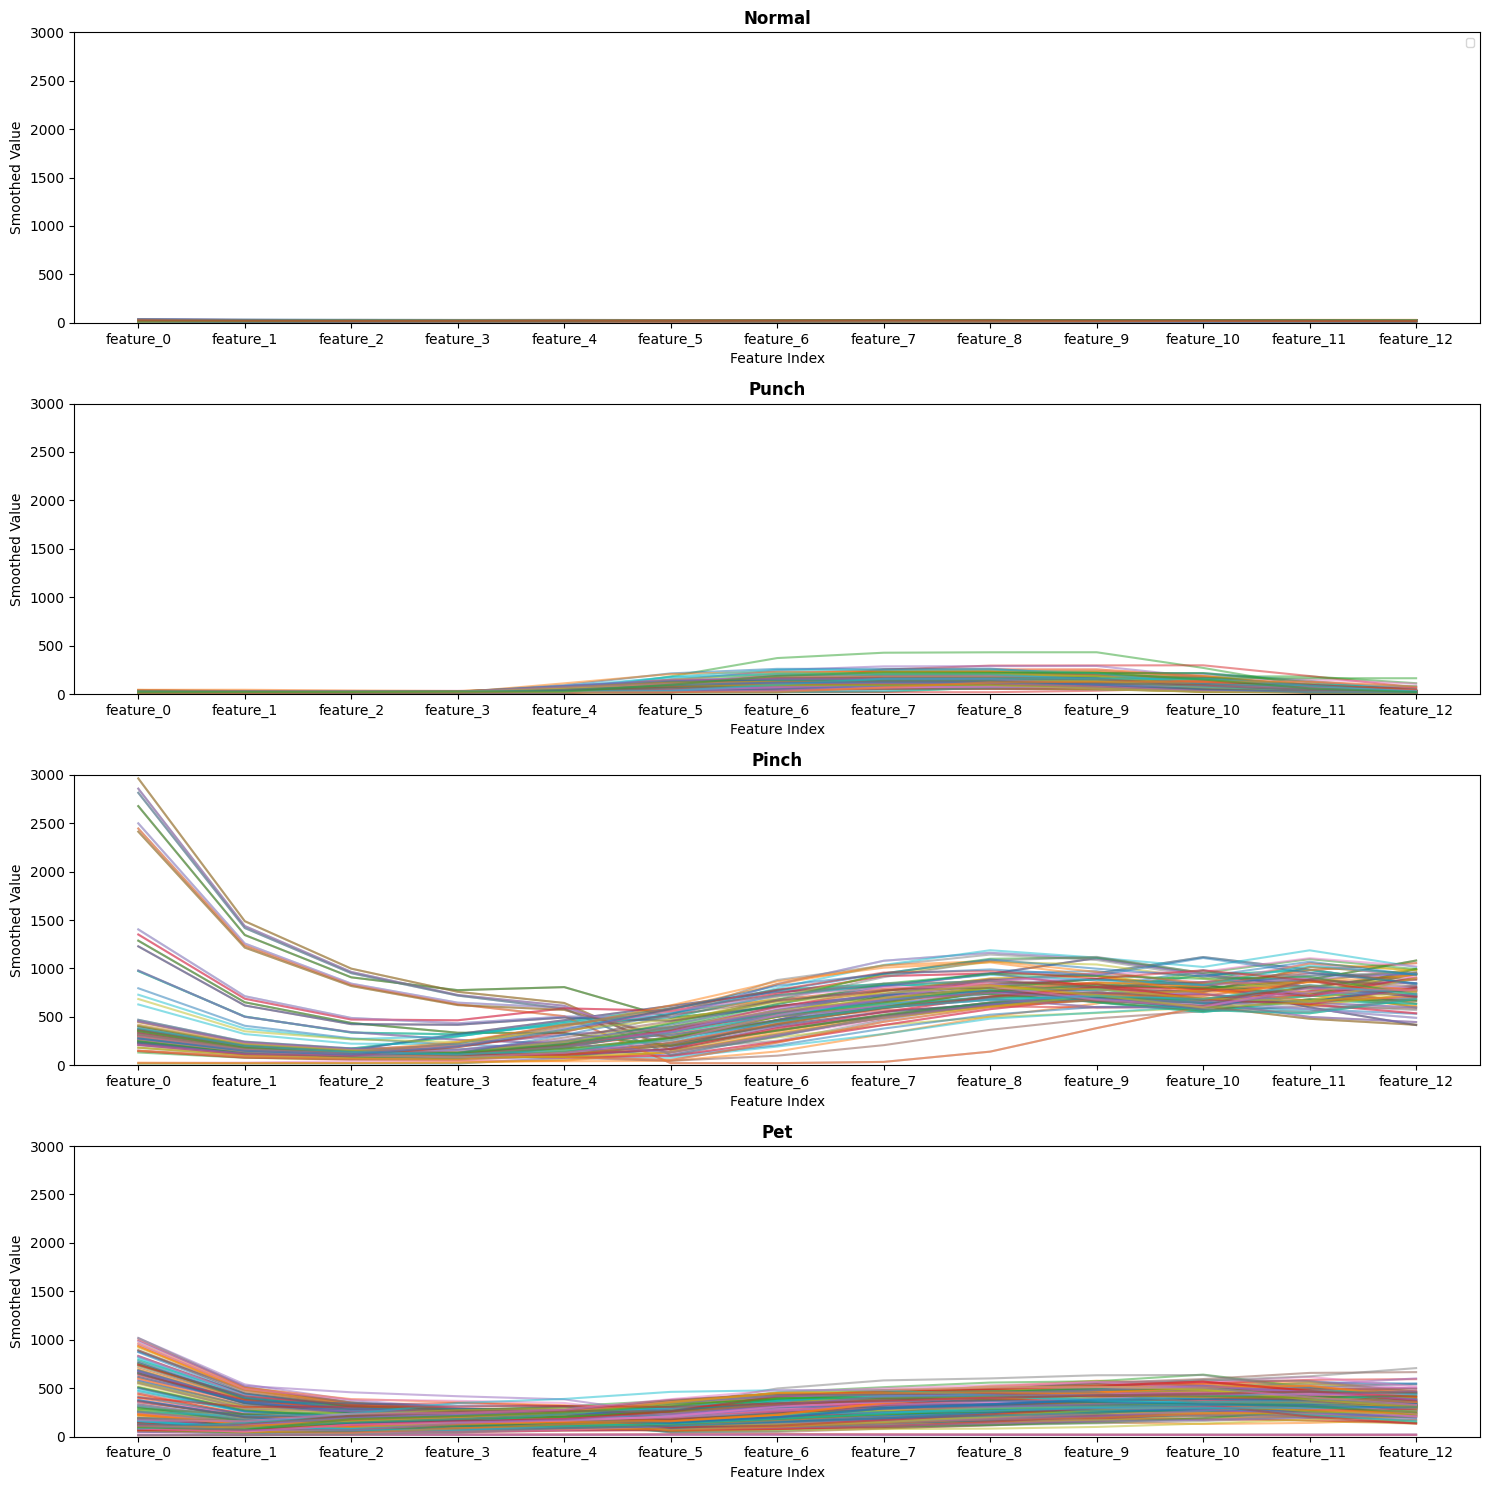

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class ProcessData():
    def __init__(self, data):
        self.data = pd.read_csv(data, usecols=range(13)).to_numpy()
    
    def data_process(self):
        data_2d = self.data.reshape(len(self.data), 13)
        df = pd.DataFrame(data_2d, columns=[f'feature_{i}' for i in range(13)])
        return df

# 데이터 로드
normal = ProcessData('normal.csv').data_process()
punch = ProcessData('punch.csv').data_process()
pinch = ProcessData('pinch.csv').data_process()
pet = ProcessData('pet.csv').data_process()

def plot_smooth(normal, punch, pinch, pet, window=5):
    datasets = [normal, punch, pinch, pet]
    titles = ['Normal', 'Punch', 'Pinch', 'Pet']

    plt.figure(figsize=(13, 15))  # 전체 Figure 크기 설정
    
    for i, (df, title) in enumerate(zip(datasets, titles)):
        plt.subplot(4, 1, i+1)  # 4행 1열 서브플롯

        # 각 행(Row)마다 하나의 그래프를 그림 (이동 평균 적용)
        for index, row in df.iterrows():
            smoothed_row = pd.Series(row.values).rolling(window=window, min_periods=1).mean()  # 이동 평균 적용
            plt.plot(df.columns, smoothed_row, alpha=0.5)

        plt.title(title, fontsize=12, fontweight="bold")  # 각 서브플롯에 제목 추가
        plt.xlabel('Feature Index')
        plt.ylabel('Smoothed Value')
        plt.ylim([0, 3000])  # Y축 범위 설정

        # 범례는 첫 번째 그래프에서만 추가
        if i == 0:
            plt.legend(loc='upper right', ncol=2, fontsize=8)

    plt.tight_layout()  # 간격 조정
    plt.show()

# 이동 평균 적용된 플롯 실행 (window 크기 = 5)
plot_smooth(normal, punch, pinch, pet, window=5)
